## Financial Sentiment Analysis
 <p>
 WMG9B7-15 - Artificial Intelligence & Deep Learning<br>
 u5696284<br>
 A sentiment analysis using Twitter Financial News dataset.
 <p>

### README
1. Create virtual environment and activate it.
2. Install the kernel package inside that venv:
~~~bash
    python -m pip install ipykernel
~~~
3. Open notebook and select this venv for kernel
4. Now, run all cells in sequence starting from Phase 0 til last cell in Phase 3.
<br>


### Phase 0: Setup & Environment

In [87]:
#  Install required dependencies

%pip install  numpy pandas matplotlib scikit-learn transformers datasets evaluate torch ipywidgets -q

Note: you may need to restart the kernel to use updated packages.


In [88]:
# Import libraries for data handling, visualisation, ML and Deep Learning

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import random
import torch
from datasets import load_dataset
import re
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.utils import compute_class_weight
from transformers import AutoTokenizer, AutoModelForSequenceClassification, get_linear_schedule_with_warmup
from torch.utils.data import Dataset, DataLoader
import torch.nn as nn
import torch.optim as optim


In [89]:
# Set seeds across all libraries to ensure reproducibility

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False
torch.cuda.manual_seed_all(SEED)

### Phase 1: Data Loading & Exploration

In [90]:
ds = load_dataset("zeroshot/twitter-financial-news-sentiment")

In [91]:
print(ds)
# Splitting ds into training and testing dataset
train_data = ds['train']
test_data = ds['validation']

DatasetDict({
    train: Dataset({
        features: ['text', 'label'],
        num_rows: 9543
    })
    validation: Dataset({
        features: ['text', 'label'],
        num_rows: 2388
    })
})


In [92]:
# Map integer labels to human-readable class names

LABEL_MAP = {0:'Bearish', 1:'Bullish', 2:'Neutral'}

**Label Mapping:**
- 0: Bearish
- 1: Bullish
- 2: Neutral

In [93]:
# Converting train and test python dict to pandas dataframe
train_df = pd.DataFrame(train_data)
test_df = pd.DataFrame(test_data)

In [94]:
# Checking the shape of the dataframes
print(train_df.shape)
print(test_df.shape)

(9543, 2)
(2388, 2)


In [95]:
# Previews first five rows of training data

train_df.head()

,text,label
0,$BYND - JPMorgan reels in expectations on Beyo...,0
1,$CCL $RCL - Nomura points to bookings weakness...,0
2,"$CX - Cemex cut at Credit Suisse, J.P. Morgan ...",0
3,$ESS: BTIG Research cuts to Neutral https://t....,0
4,$FNKO - Funko slides after Piper Jaffray PT cu...,0


In [96]:
# Display one example per class to explore labels and text data
for label_id, label_name in LABEL_MAP.items():
    idx = train_df[train_df['label'] == label_id].index[50]
    print(f"\nLabel {label_id} ({label_name}) at index {idx}")
    print(train_df.loc[idx, "text"])


Label 0 (Bearish) at index 50
Canada Goose stock price target cut to $50 from $65 at CFRA

Label 1 (Bullish) at index 176
Analysts See 18% Gains Ahead For The Holdings Of The First Trust Dow Jones Internet Index Fund ETF

Label 2 (Neutral) at index 446
Bank of Israel expands its crisis QE with $13.6 billion in bond buying https://t.co/xEMWn1vjAO


In [97]:
train_df.dtypes # Checking type of data

text       str
label    int64
dtype: object

In [98]:
train_df['text'].duplicated().sum()  # Returns number of duplicate rows

np.int64(0)

In [99]:
train_df.isna().sum() # Checking for missing values

text     0
label    0
dtype: int64

In [100]:
# Checking class distribution
counts = train_df["label"].value_counts().rename(index=LABEL_MAP)
pct = train_df["label"].value_counts(normalize=True).mul(100).rename(index=LABEL_MAP)

summary = pd.DataFrame({"count": counts, "percentage": pct})
print(summary)

         count  percentage
label                     
Neutral   6178   64.738552
Bullish   1923   20.150896
Bearish   1442   15.110552


<p>Class imbalance identified. It can be observed that ~65% of the dataset is made up of neutral statements while the Bullish and Bearish statements are only 20% and 15% respectively. This could result in a misleading accuracy where the model accurately predicts the majority class to achieve artificially high scores despite failing to identify the minority class. In this case, precision and recall are better metrics to know how well the model identifies the minority classes but a better option would be F1 Score as it is a harmonic mean of both Precision and Recall and we would specifically use Macro F1 Score as it treats all classes equally, making it superior for imbalanced datasets where minority class performance matters.<br> To address class imbalance, class_weight='balanced' will be used for the baseline and weighted cross-entropy loss for FinBERT.</p>

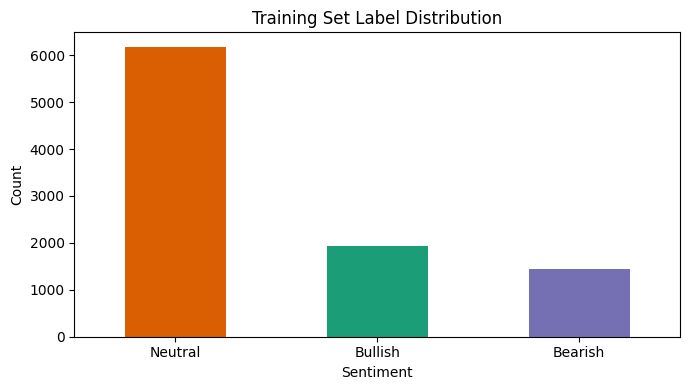

In [101]:
# Plot: Label distribution
label_counts = train_df["label"].map(LABEL_MAP).value_counts()

plt.figure(figsize=(7, 4))
label_counts.plot(kind="bar", color=["#d95f02", "#1b9e77", "#7570b3"])
plt.title("Training Set Label Distribution")
plt.xlabel("Sentiment")
plt.ylabel("Count")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

### Phase 2: TF-IDF + Logistic Regression (Baseline)

In [102]:
# Text Cleaning using RegEx
# Normalize tweet text for modeling by removing cashtags/URLs/mentions, stripping symbols,
# and lowercasing so the sentiment model learns from consistent headline words.

def clean_tweet_headline(text: str) -> str:
    text = re.sub(r'\$\w+', '', text)       # remove cashtags e.g. $AAPL
    text = re.sub(r'http\S+', '', text)     # remove URLs
    text = re.sub(r'@\w+', '', text)        # remove mentions e.g. @user
    text = re.sub(r'#', '', text)           # remove hashtag symbol, while retaining word
    text = text.lower()                     # text converted to lowercase
    text = re.sub(r'[^a-z\s]', '', text)    # remove anything that isn't a letter or whitespace
    return text.strip()

train_df['text'] = train_df['text'].apply(clean_tweet_headline)
test_df['text'] = test_df['text'].apply(clean_tweet_headline)

In [103]:
# Verify text cleaning output: confirm cashtags, URLs and punctuation have been removed

for label_id, label_name in LABEL_MAP.items():
    idx = train_df[train_df['label'] == label_id].index[50]
    print(f"\nLabel {label_id} ({label_name}) at index {idx}")
    print(train_df.loc[idx, "text"])


Label 0 (Bearish) at index 50
canada goose stock price target cut to  from  at cfra

Label 1 (Bullish) at index 176
analysts see  gains ahead for the holdings of the first trust dow jones internet index fund etf

Label 2 (Neutral) at index 446
bank of israel expands its crisis qe with  billion in bond buying


<p>The cashtags, URLs, and mentions have been removed. Lowercase has been applied. Punctuation stripped.<br>Limitation: the cleaning function also removes any numbers mentioned as percentages which is why you see gaps like "cut to   from   at"</p>

In [104]:
# Detected Duplicates after Cleaning

print('Duplicates in Training Data post-cleaning:',train_df['text'].duplicated().sum())
print('Duplicates in Test Data post-cleaning:',test_df['text'].duplicated().sum())

Duplicates in Training Data post-cleaning: 260
Duplicates in Test Data post-cleaning: 25


In [105]:
# Inspect duplicate texts — note some rows have become empty strings post-cleaning

train_df[train_df.duplicated(subset=['text'], keep=False)].sort_values('text').head(20) 

,text,label
3943,,2
3948,,2
3949,,2
3950,,2
4681,,2
4682,,2
4683,,2
8160,,2
8224,,2
8237,,2


In [106]:
# Inspect duplicate texts — note some rows have become empty strings post-cleaning

test_df[test_df.duplicated(subset=['text'], keep=False)].sort_values('text').head(20) 

,text,label
2034,,2
2061,,2
2062,,2
2064,,2
293,allergan form allergan stock marketscreener,2
294,allergan form allergan stock marketscreener,2
512,b riley offers of senior notes,2
521,b riley offers of senior notes,2
2301,canopy growth premarket on new cannabis licen...,1
2340,canopy growth premarket on new cannabis licen...,1


In [107]:
# Count empty rows in text column — these appear post-cleaning when tweets have only cashtags or URLs

print('Empty rows in training data text column:',(train_df['text']== '').sum())
print('Empty rows in test data text column:',(test_df['text']== '').sum())

Empty rows in training data text column: 17
Empty rows in test data text column: 4


In [108]:
# Drop duplicates and empty rows in text column

train_df.replace('', pd.NA, inplace=True)
train_df.dropna(inplace=True)
test_df.replace('', pd.NA, inplace=True)
test_df.dropna(inplace=True)

train_df = train_df.drop_duplicates(subset=['text'], keep='first')
test_df = test_df.drop_duplicates(subset=['text'], keep='first')

In [109]:
# Helper Function to verify

def verify_cols(df, col):
    # Check for empty rows
    empty = (df[col] == '').sum()
    if empty == 0:
        print(f'No empty rows found in {col} column.')
    else:
        print(f'Empty rows in {col} column: {empty}')

    # Check for NA values
    na = (df[col].isna().sum())
    if na == 0:
        print(f'No missing values in {col} column.')
    else:
        print(f'Missing Values in {col} column: {na}')

    # Check for Duplicates
    dup = df[col].duplicated().sum()
    if dup == 0:
        print(f'No duplicate values in {col} column.')
    else:
        print(f'Duplicate Values in {col} column: {dup}')
    print('\n')      

verify_cols(train_df, 'text')         
verify_cols(test_df, 'text')                  

No empty rows found in text column.
No missing values in text column.
No duplicate values in text column.


No empty rows found in text column.
No missing values in text column.
No duplicate values in text column.




Detected empty and duplicate rows in the text column as an effect of text cleaning, in both training and test data.
<br>Dropped 17 empty rows from training data and 4 from test data - Tweets became empty after cleaning and had no semantic meaning 
<br>Dropped 260 duplicate rows from training data and 25 from test data - Distinct Tweets became identical and redundant after removal of Cashtags and URLs and had to be dropped to avoid frequency inflation of classes. 

In [110]:
# TF-IDF + Logistic Regression Pipeline

tfidf_lr_pipeline = Pipeline([
    ('tfidf', TfidfVectorizer(max_features=10000, ngram_range=(1, 1), stop_words='english')),
    ('logreg', LogisticRegression(class_weight='balanced', max_iter=1000))
])

10,000 features was selected as a balance between vocabulary coverage and feature sparsity, appropriate for a dataset of ~9,500 short tweets.<br>Unigrams were chosen for the baseline to keep it interpretable and computationally lightweight.<br>class_weight='balanced' to account for class imbalance and max_iter=1000 to avoid failure of convergence. 

In [111]:
# Train pipeline and generate predictions

tfidf_lr_pipeline.fit(train_df['text'], train_df['label'])
pred = tfidf_lr_pipeline.predict(test_df['text'])

In [112]:
# Evaluate baseline model performance

print(classification_report(test_df['label'], pred, target_names=list(LABEL_MAP.values())))

              precision    recall  f1-score   support

     Bearish       0.57      0.69      0.63       344
     Bullish       0.69      0.75      0.72       472
     Neutral       0.90      0.83      0.87      1546

    accuracy                           0.80      2362
   macro avg       0.72      0.76      0.74      2362
weighted avg       0.81      0.80      0.80      2362



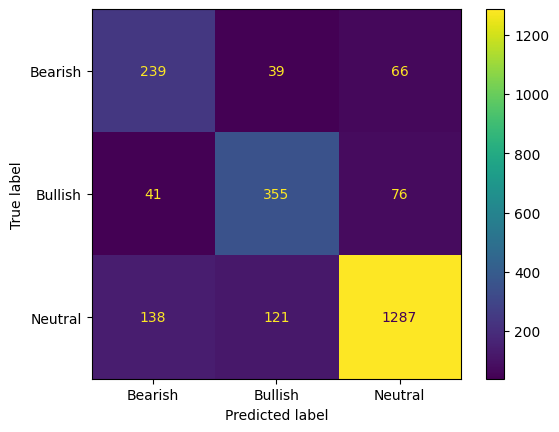

In [113]:
# Visualize misclassification patterns across classes

cm = confusion_matrix(test_df['label'], pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Bearish','Bullish', 'Neutral'])
disp.plot()

In [114]:
# Top predictive features per class (Logistic Regression interpretability)

feature_names = tfidf_lr_pipeline.named_steps['tfidf'].get_feature_names_out()
coef = tfidf_lr_pipeline.named_steps['logreg'].coef_

for i, class_name in LABEL_MAP.items():
    top10_idx = np.argsort(coef[i])[-10:][::-1] # indices of top 10 coefficents 
    print(f"\nTop 10 features for {class_name}:")
    for idx in top10_idx:
        print(f"  {feature_names[idx]}: {coef[i][idx]:.4f}")


Top 10 features for Bearish:
  downgraded: 4.1125
  lower: 3.9949
  misses: 3.7626
  falls: 3.1119
  cut: 2.5605
  sues: 2.4353
  weak: 2.3559
  cuts: 2.3323
  dumping: 2.2506
  slips: 2.2194

Top 10 features for Bullish:
  raised: 3.8669
  bullish: 3.7797
  beats: 3.3898
  rises: 3.1282
  higher: 2.9787
  pre: 2.7596
  positive: 2.7355
  upgraded: 2.6812
  jump: 2.5332
  high: 2.3883

Top 10 features for Neutral:
  declares: 2.4814
  marketscreener: 2.2313
  does: 1.9223
  preview: 1.8574
  presentation: 1.7643
  trump: 1.6491
  reports: 1.5416
  results: 1.4991
  fed: 1.4915
  conference: 1.4762


### Result Interpretation
A naive classifier that always predicts the majority class (Neutral) would achieve high accuracy but near-zero macro F1, since it would fail entirely on Bearish and Bullish. The baseline macro F1 of 0.74 therefore represents genuine learning across all three classes, but remains insufficient for reliable financial use given the minority class performance.

Neutral class scores higher not only because it has the highest number of examples which allows the model to generalize better to the particular class but also because the TF-IDF vectorizer we use ignores word order and contextual meaning due to its bag-of-words nature which penalizes bullish and bearish statements as they require contextual meaning to be interpreted correctly compared to the majority class which is neutral in nature and does not require contextual meaning.

This is confirmed by the confusion matrix. The model misclassifies  39 bearish statements as bullish and 66 as neutral, telling traders that a stock will rise or hold when it will fall. Similarly, 41 bullish statements are misclassified as bearish and 76 as neutral causing traders to either sell appreciating stocks or miss investment opportunities entirely. Both failure modes carry significant financial consequences and are equally dangerous in practice.

We also look at the top predictive features per class to understand how the model works. The predictive features for Bearish and Bullish classes are strongly class-discriminative words that intuitively align with their respective sentiments which gives the impression that the model is capturing the sentiment, but TF-IDF has no notion of sentiment whatsoever. It just weights words by frequency within a class relative to their rarity across the corpus and the LR model trains to associate those words to their classes. However, it is slightly different for the Neutral Class whose top features are common words that don't inherently convey neutrality . Because these words appear across all three classes, TF-IDF assigns them a low IDF weight and suppresses them as features. Yet, they are still associated to Neutral class by the LR Model because of the class imbalance which creates a spurious statistical association with the neutral class.

Hence, the inability to capture contextual meaning and compounded by class imbalance motivate the use of FinBERT in the next phase, a specialized BERT-based NLP model pre-trained on financial data that explicitly models word order, context, and domain-specific semantics.

### Phase 3: FinBERT

In [115]:
# Using raw data for Phase 3

train_df_raw = pd.DataFrame(train_data)
test_df_raw = pd.DataFrame(test_data)

In [116]:
train_df_raw.head()

,text,label
0,$BYND - JPMorgan reels in expectations on Beyo...,0
1,$CCL $RCL - Nomura points to bookings weakness...,0
2,"$CX - Cemex cut at Credit Suisse, J.P. Morgan ...",0
3,$ESS: BTIG Research cuts to Neutral https://t....,0
4,$FNKO - Funko slides after Piper Jaffray PT cu...,0


In [117]:
# Analyse token length distribution to determine a safe max_length for the tokenizer

tokenizer = AutoTokenizer.from_pretrained('ProsusAI/finbert')

lengths = tokenizer(
    list(train_df_raw['text']),
    truncation=False,       # disable truncation to capture true token length
    return_length=True      # return token count per sequence
)['length']

len_arr = np.array(lengths)
per = np.percentile(len_arr, (95, 99, 100))
print(f'95th Percentile: {per[0]}\n99th Percentile: {per[1]}\n100th Percentile: {per[2]}',)

95th Percentile: 51.0
99th Percentile: 57.0
100th Percentile: 82.0


To decide on a value for max_length, we run the tokenizer on the training data without the max_length cap and inspect the 95th, 99th and 100th percentile of token lengths.<br>The 100th percentile of raw token lengths is 82; adding 2 special tokens [CLS] and [SEP] gives max_length=84.

In [118]:
class FinBERTDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_length=84):
        """PyTorch Dataset wrapper: tokenizes texts and stores labels 
        as tensors for DataLoader compatibility."""
        
        self.encodings = tokenizer(
            list(texts), max_length=max_length, padding = 'max_length', truncation=True
            )
        self.labels = list(labels)

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        item = {key: torch.tensor(val[idx]) for key, val in self.encodings.items()}
        item['labels'] = torch.tensor(self.labels[idx])
        return item    

In [119]:
# Initialise FinBERTDataset class for both training and test dataset

train_dataset = FinBERTDataset(list(train_df_raw['text']),list(train_df_raw['label']), tokenizer)
test_dataset = FinBERTDataset(list(test_df_raw['text']), list(test_df_raw['label']), tokenizer)

In [120]:
# Defining Dataloaders for both set of data

train_dataloader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_dataloader = DataLoader(test_dataset, batch_size=32, shuffle=False)

Batch size is selected considering the small size of the dataset.<br>Training data is shuffled to ensure each batch has a mix of classes, which stabilises gradient updates during training.

In [121]:
# Loading the FinBERT model

model = AutoModelForSequenceClassification.from_pretrained(
    'ProsusAI/finbert',
    num_labels = 3
)

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: ProsusAI/finbert
Key                          | Status     |  | 
-----------------------------+------------+--+-
bert.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [122]:
# Hyperparameters
learning_rate = 2e-5

# Compute inverse-frequency weights per class to penalise misclassification of minority classes
class_weight = compute_class_weight(class_weight='balanced', classes=np.unique(train_df_raw['label']), y=train_df_raw['label'])

A small learning rate is selected to avoid Catastrophic Forgetting problem where the pre-trained knowledge is erased during learning of new knowledge. 

In [123]:
# Initialize AdamW optimizer and set up loss function

optimizer = optim.AdamW(model.parameters(), lr=learning_rate)
criterion = nn.CrossEntropyLoss(weight = torch.tensor(class_weight, dtype=torch.float))

AdamW is the standard optimiser for BERT fine-tuning; decouples weight decay from gradient updates

In [124]:
# Linear warmup scheduler: gradually decays LR to zero over training, stabilising fine-tuning

EPOCHS = 4
total_steps = len(train_dataloader) * EPOCHS

scheduler = get_linear_schedule_with_warmup(
    optimizer,
    num_warmup_steps=0,
    num_training_steps=total_steps
)

In [125]:
# Training Loop

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

model.to(device)
criterion = criterion.to(device)  # move loss weights to same device

for epoch in range(EPOCHS):
    model.train()  # sets model to training mode (enables dropout etc.)
    total_loss = 0
    
    for batch in train_dataloader:
        # move batch to GPU/CPU
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels = batch['labels'].to(device)
        
        optimizer.zero_grad()  # clear gradients from previous step
        
        outputs = model(input_ids=input_ids, attention_mask=attention_mask)  # forward pass
        
        loss = criterion(outputs.logits, labels)  # compute loss
        
        loss.backward()  # backpropagate
        
        optimizer.step()  # update weights

        scheduler.step() # decays learning rate
        
        total_loss += loss.item()
    
    print(f'Epoch {epoch+1}/{EPOCHS}, Loss: {total_loss/len(train_dataloader):.4f}')

Epoch 1/4, Loss: 0.7339
Epoch 2/4, Loss: 0.3574
Epoch 3/4, Loss: 0.2088
Epoch 4/4, Loss: 0.1300


Declining loss confirms that the model is learning.

In [126]:
# Evaluation Loop

model.eval()
all_preds = []
all_labels = []

with torch.no_grad():
    for batch in test_dataloader:
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels = batch['labels'].to(device)
        
        outputs = model(input_ids=input_ids, attention_mask=attention_mask)
        preds = torch.argmax(outputs.logits, dim=1) # take highest scoring class as prediction
        
        all_preds.extend(preds.cpu().numpy())       # move to cpu before converting to numpy
        all_labels.extend(labels.cpu().numpy())

print(classification_report(all_labels, all_preds, target_names=['Bearish', 'Bullish', 'Neutral']))

              precision    recall  f1-score   support

     Bearish       0.72      0.87      0.79       347
     Bullish       0.81      0.82      0.82       475
     Neutral       0.94      0.89      0.91      1566

    accuracy                           0.87      2388
   macro avg       0.82      0.86      0.84      2388
weighted avg       0.88      0.87      0.88      2388



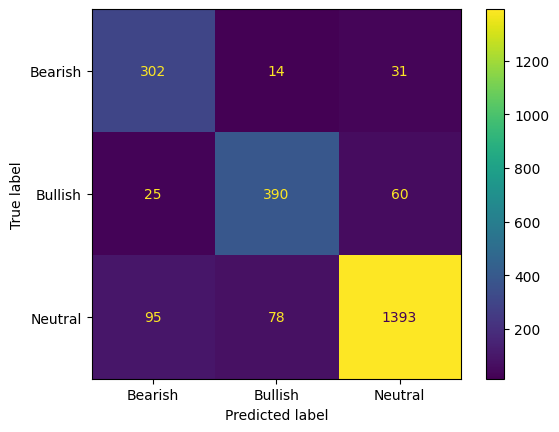

In [ ]:
# Visualise misclassification patterns across classes

cm = confusion_matrix(all_labels, all_preds)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Bearish','Bullish', 'Neutral'])
disp.plot()

In [128]:
# FinBERT prediction confidence per class
# Softmax over logits gives calibrated probability distribution across all three classes

model.eval()
examples = {name: test_df_raw[test_df_raw['label'] == idx].iloc[0]['text'] 
            for idx, name in LABEL_MAP.items()}

with torch.no_grad():
    for class_name, text in examples.items():
        inputs = tokenizer(text, return_tensors='pt', 
                          max_length=84, padding='max_length', 
                          truncation=True).to(device)
        logits = model(**inputs).logits                          # raw unnormalised scores per class
        probs = torch.softmax(logits, dim=1).cpu().numpy()[0]    # convert to probabilities summing to 1
        print(f"\nTrue label: {class_name}")
        print(f"Text: {text}")
        for idx, name in LABEL_MAP.items():
            print(f"  {name}: {probs[idx]:.4f}")


True label: Bearish
Text: $ALLY - Ally Financial pulls outlook https://t.co/G9Zdi1boy5
  Bearish: 0.9869
  Bullish: 0.0076
  Neutral: 0.0056

True label: Bullish
Text: $ABEO as expected, keeps going higher. Cantor doubled its price target this morning to $4
  Bearish: 0.0053
  Bullish: 0.9844
  Neutral: 0.0103

True label: Neutral
Text: AM Best Revises Outlooks to Stable for Sublimity Insurance Company https://t.co/WPcVIMko76 https://t.co/glnxmA3iIv
  Bearish: 0.2022
  Bullish: 0.0084
  Neutral: 0.7894


### Result Interpretation
After training the FinBERT model on the Financial Tweets dataset, significant improvement has been observed relative to the results of the baseline model. The overall Macro F1 score has increased from 0.74 to 0.84. Next, the recall of Bearish has jumped from 0.69 to 0.87, and for Bullish, a meaningful increase of 0.75 to 0.82, suggesting that both minority classes showed significant improvement. This means that the model's generalization on the minority classes has improved and misclassification of them is reduced. The Neutral class remains strong with slight improvement in F1-score (0.87 to 0.91).<br>

This is confirmed by the confusion matrix. The misclassification of Bearish class for Bullish and Neutral classes dropped significantly (from 39+66 to 14+31). The same can be said for Bullish class also(from 41+76 to 25+60).<br>

Next, we look at some confidence outputs for each class prediction to understand how the model makes predictions. Looking at the Bearish and Bullish predictions, it is clear that the model is highly certain on clear directional tweets, 0.99 for Bearish "$ALLY - Ally Financial pulls..." and 0.98 for Bullish "...keeps going higher.". However the neutral example reveals a possible limitation. The model correctly classifies the tweet but with reduced confidence and assigns 0.20 probability to Bearish.This suggests that the tweet contains lexical features that the model associates with negative sentiment. It could be 'Revises' as it can be used as positive or negative sentiment but the model was pre-trained on data that showed 'Revises' as negative. So this could introduce bias in the model. This is just a hypothesis and not proven fact.

Overall, the use of FinBERT model has significantly improved the reliability of the model for real world financial practices. Particularly, with the improvement in Bearish class, the model is able to predict better about which stocks are going to fall so traders can sell them early on and avoid the risk of losing their investment.